## Partial Derivatives — Visualizing the Surface

A single-variable function $f(x)$ is a **curve**, and its derivative is the
slope of that curve. A two-variable function $f(x, y)$ is a **surface** — a
landscape sitting above the flat $xy$-plane. "The slope" is now ambiguous:
slope *in which direction*?

A **partial derivative** answers that by fixing a direction:

- $\frac{\partial f}{\partial x}$ — the slope if you walk in the **x-direction only** (y held fixed)
- $\frac{\partial f}{\partial y}$ — the slope if you walk in the **y-direction only** (x held fixed)

### What the plot below shows

We use $f(x, y) = x^2 + y^2$ — a **bowl** with its minimum at the origin.
At the marked point on the surface, two colored lines show the two partial
slopes:

- one line runs in the **x-direction** — its steepness is $\frac{\partial f}{\partial x} = 2x$
- one line runs in the **y-direction** — its steepness is $\frac{\partial f}{\partial y} = 2y$

Each partial is literally the slope of the surface along one axis. Together,
these two numbers describe how the landscape tilts at that point — which is
exactly the information gradient descent will use (tomorrow) to decide which
way is downhill.

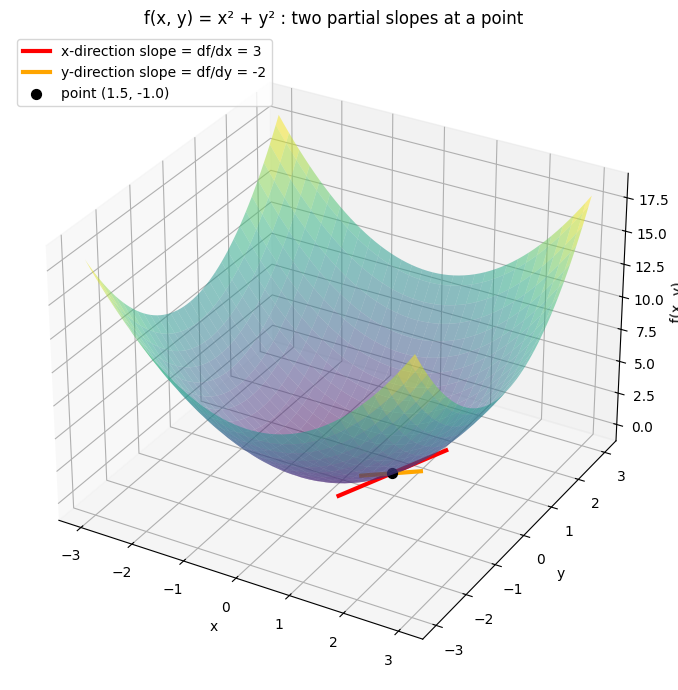

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (enables 3D projection)

# f(x, y) = x^2 + y^2 : a bowl.  Partials: df/dx = 2x, df/dy = 2y
f = lambda x, y: x**2 + y**2

# the surface
X = np.linspace(-3, 3, 60)
Y = np.linspace(-3, 3, 60)
X, Y = np.meshgrid(X, Y)
Z = f(X, Y)

# the point where we show the two partial slopes
px, py = 1.5, -1.0
pz = f(px, py)
dfdx = 2*px      # slope in x-direction at the point
dfdy = 2*py      # slope in y-direction at the point

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, alpha=0.5, cmap="viridis", edgecolor="none")

# short tangent line in the x-direction (y fixed): slope = dfdx
tx = np.linspace(px - 1, px + 1, 20)
ax.plot(tx, np.full_like(tx, py), pz + dfdx*(tx - px),
        color="red", lw=3, label=f"x-direction slope = df/dx = {dfdx:.0f}")

# short tangent line in the y-direction (x fixed): slope = dfdy
ty = np.linspace(py - 1, py + 1, 20)
ax.plot(np.full_like(ty, px), ty, pz + dfdy*(ty - py),
        color="orange", lw=3, label=f"y-direction slope = df/dy = {dfdy:.0f}")

ax.scatter([px], [py], [pz], color="black", s=50, label=f"point ({px}, {py})")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("f(x, y)")
ax.set_title("f(x, y) = x² + y² : two partial slopes at a point")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

##  Application of partials derivatives in of a two-parameter loss function (weight + bias)

This is why partial derivatives matter. Last week the model had one dial, $w$.
A real model has more — the simplest upgrade adds a **bias** $b$, giving two
parameters. To train it, we need the partial of the loss with respect to *each*.

### The model and loss

Add a bias to last week's model:

$$\hat{y} = wx + b$$

- $w$ controls the **slope** of the line; $b$ controls where it **shifts** (offset).
- $x, y$ are fixed data; **$w$ and $b$ are the two variables** we tune.

Squared-error loss for one point:

$$L(w, b) = (wx + b - y)^2$$

### The two partials (freeze the other parameter, then differentiate)

**With respect to $w$** (treat $b - y$ as a constant, expand, differentiate):

$$\frac{\partial L}{\partial w} = 2x(wx + b - y) = 2x(\hat{y} - y)$$

**With respect to $b$** (treat $wx - y$ as a constant, expand, differentiate):

$$\frac{\partial L}{\partial b} = 2(wx + b - y) = 2(\hat{y} - y)$$

### What the pair tells us

$$\frac{\partial L}{\partial w} = 2x(\hat{y} - y), \qquad \frac{\partial L}{\partial b} = 2(\hat{y} - y)$$

Both are proportional to the **error** $(\hat{y} - y)$. Two things to notice:

- The $w$-partial carries an extra factor of **$x$**; the $b$-partial doesn't.
  This mirrors the model: $w$ is multiplied by $x$ (so its effect is scaled by
  $x$), while $b$ is added directly (raw error). The structure of the *model*
  shows up in the structure of the *partials*.
- The $w$-partial is *identical* to last week's one-parameter result. Adding a
  bias didn't break anything — it just added a second partial alongside it.

### Why this is the point of the week

These two partials say how to nudge *each* dial to reduce the loss. Next (Day 2)
we bundle them into one object — the **gradient**
$\nabla L = \left(\frac{\partial L}{\partial w},\, \frac{\partial L}{\partial b}\right)$ —
and gradient descent then steps *both* dials at once, each in its own downhill
direction. This is exactly what trains linear regression (with a real
weight + bias model) in the capstone.

## Self-check — Day 1 (Partial Derivatives)

Answer each out loud before opening the answers.

**Q1.** In one sentence: what is a partial derivative, and what's the one-step
recipe for computing it?

**Q2.** For $f(x, y) = x^2 + 3xy + y^2$, find both $\frac{\partial f}{\partial x}$
and $\frac{\partial f}{\partial y}$.

**Q3.** Why does the term $x^2 y$ give $2xy$ when differentiated by $x$, but
$x^2$ when differentiated by $y$?

**Q4.** In training, the variables we take partials *with respect to* are the
model's ______, not the ______. (Fill both blanks and say why it matters.)

**Q5.** For the two-parameter loss $L(w, b) = (wx + b - y)^2$, the partials are
$\frac{\partial L}{\partial w} = 2x(\hat{y}-y)$ and $\frac{\partial L}{\partial b} = 2(\hat{y}-y)$.
Why does the $w$-partial have an extra factor of $x$ but the $b$-partial doesn't?

---

<details>
<summary>Answers</summary>

**A1.** It's how a multivariable function changes as you nudge *one* variable,
holding the others fixed. Recipe: treat every other variable as a constant,
then differentiate normally with the single-variable rules.

**A2.** $\frac{\partial f}{\partial x} = 2x + 3y$ (freeze $y$: $x^2 \to 2x$,
$3xy \to 3y$, $y^2 \to 0$). $\frac{\partial f}{\partial y} = 3x + 2y$ (freeze
$x$: $x^2 \to 0$, $3xy \to 3x$, $y^2 \to 2y$).

**A3.** Differentiating by $x$, the $y$ is a constant multiplier on $x^2$, so
$x^2 y \to (2x)\cdot y = 2xy$. Differentiating by $y$, the $x^2$ is the constant
multiplier on $y^1$, so $x^2 y \to x^2 \cdot 1 = x^2$. Same term, different
frozen variable.

**A4.** The model's **parameters** (the dials, e.g. $w$ and $b$), not the
**data** (which stays fixed). It matters because the gradient and gradient
descent move through *parameter space* — "learning = adjusting parameters." If
you picture moving through the data's space, the mental model breaks.

**A5.** In the model $\hat{y} = wx + b$, $w$ is multiplied by $x$, so its
influence on the loss is scaled by $x$ — that $x$ carries through to its partial.
$b$ is added directly (no $x$ attached), so its partial is just the raw error.
The model's structure shows up in the partials.

</details>